# Model Development 

We'll start a baseline using Logistic Regression that help us classify claim/no claim using sigmoid. 

We'll use its metrics to compare against Tree-based ensembles (RF, XGBoost, LightGBM) to see where multi-feature classification excels for underwriting.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve
)
from imblearn.combine import SMOTETomek

import warnings
warnings.filterwarnings('ignore')

# Gradient Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Hyperparameter tuning
import optuna
from optuna.samplers import TPESampler
from optuna.visualization import plot_optimization_history, plot_param_importances


import joblib
import plotly


In [4]:
data = joblib.load('scaled_data.pkl')

x_train, y_train, x_test, y_test = data.values() # unpack

x_train = pd.DataFrame(x_train)
x_test  = pd.DataFrame(x_test)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"Training: {x_train.shape[0]} samples")
print(f"Test: {x_test.shape[0]} samples")
print(f"Features: {x_train.shape[1]}")
print(f"\nClass distribution in training:")
print(y_train.value_counts())



Training: 46873 samples
Test: 11719 samples
Features: 64

Class distribution in training:
claim_status
0    43875
1     2998
Name: count, dtype: int64


Load helper functions to hlep us evaluate different models.

In [5]:
from helpers.evaluation import (find_optimal_threshold, evaluate_model, display_results)

---
# Baseline Model: Logistic Regression

We start at a baseline because it is:
- Fast to train
- Interpretable (coefficients show feature importance)
- Sets the "beat this" benchmark

`class_weight='balanced'` automatically adjusts weights inversely proportional to class frequencies.

In [6]:
all_results = []
all_models = {}

In [7]:
print(x_train.shape, y_train.shape)


(46873, 64) (46873,)


In [8]:
random: int = 0
lr_model = LogisticRegression(
    max_iter = 1000,
    class_weight = 'balanced',
    random_state = random,
    solver = 'lbfgs'
)

lr_model.fit(x_train, y_train)
lr_results, lr_proba, lr_pred = evaluate_model(
    "Logistic Regression", lr_model, x_test, y_test
)


all_results.append(lr_results)
all_models['LogisticRegression'] = lr_model

print(f"Logistic Regression : ")
print(f"  F1 Score: {lr_results['F1_Score']:.4f}")
print(f"  AUC-PR: {lr_results['AUC_PR']:.4f}")
print(f"  Optimal Threshold: {lr_results['Opt_Threshold']:.4f}")

print("\nClassification Report (at optimal threshold):")
print(classification_report(y_test, lr_pred, target_names=['No Claim', 'Claim']))


Logistic Regression : 
  F1 Score: 0.1613
  AUC-PR: 0.0917
  Optimal Threshold: 0.5564

Classification Report (at optimal threshold):
              precision    recall  f1-score   support

    No Claim       0.95      0.74      0.83     10969
       Claim       0.10      0.42      0.16       750

    accuracy                           0.72     11719
   macro avg       0.52      0.58      0.50     11719
weighted avg       0.89      0.72      0.79     11719



---
# Tree-Based Ensembles

Tree ensembles often outperform linear models on tabular data. We'll try:

1. **Random Forest** - Bagging approach, robust to overfitting
2. **XGBoost** - Gradient boosting, usually best performance
3. **LightGBM** - Faster than XGBoost, good for larger datasets

In [9]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators        = 200,
    max_depth           = 10,
    min_samples_split   = 10,
    min_samples_leaf    = 5,
    class_weight        = 'balanced_subsample',  # KEY: balanced per bootstrap sample
    random_state        = 42,
    n_jobs              = -1
)

# RF doesn't need scaled data, but we use unscaled for consistency
rf_model.fit(x_train, y_train)

# Evaluate
rf_results, rf_proba, rf_pred = evaluate_model(
    'RandomForest', rf_model, x_test, y_test
)

all_results.append(rf_results)
all_models['RandomForest'] = rf_model

print(f"Random Forest")
print(f"  F1 Score: {rf_results['F1_Score']:.4f}")
print(f"  AUC-PR: {rf_results['AUC_PR']:.4f}")

print("\nClassification Report (at optimal threshold):")
print(classification_report(y_test, rf_pred, target_names=['No Claim', 'Claim']))

Training Random Forest...
Random Forest
  F1 Score: 0.1867
  AUC-PR: 0.1062

Classification Report (at optimal threshold):
              precision    recall  f1-score   support

    No Claim       0.95      0.78      0.86     10969
       Claim       0.12      0.44      0.19       750

    accuracy                           0.75     11719
   macro avg       0.54      0.61      0.52     11719
weighted avg       0.90      0.75      0.81     11719



## XGBoost

**Key imbalance parameter:** `scale_pos_weight = (# negative) / (# positive)`

In [10]:

print("Training XGBoost...")

# Calculate scale_pos_weight for imbalance | aka ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"  scale_pos_weight = {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators        = 200,
    max_depth           = 6,
    learning_rate       = 0.1,
    scale_pos_weight    = scale_pos_weight,  # KEY: handles imbalance
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    min_child_weight    = 5,
    random_state        = 42,
    use_label_encoder   = False,
    eval_metric         = 'logloss',
    n_jobs              = -1
)

xgb_model.fit(x_train, y_train)

# Evaluate
xgb_results, xgb_proba, xgb_pred = evaluate_model(
    'XGBoost', xgb_model, x_test, y_test
)

all_results.append(xgb_results)
all_models['XGBoost'] = xgb_model

print(f"XGBOOST!")
print(f"  F1 Score: {xgb_results['F1_Score']:.4f}")
print(f"  AUC-PR: {xgb_results['AUC_PR']:.4f}")

print("\nClassification Report (at optimal threshold):")
print(classification_report(y_test, xgb_pred, target_names=['No Claim', 'Claim']))

Training XGBoost...
  scale_pos_weight = 14.63
XGBOOST!
  F1 Score: 0.1718
  AUC-PR: 0.1002

Classification Report (at optimal threshold):
              precision    recall  f1-score   support

    No Claim       0.95      0.70      0.81     10969
       Claim       0.10      0.50      0.17       750

    accuracy                           0.69     11719
   macro avg       0.53      0.60      0.49     11719
weighted avg       0.90      0.69      0.77     11719



## LightGBM

**Key imbalance parameter:** `is_unbalance=True` or `scale_pos_weight`

In [11]:
print("Training LightGBM...")

lgbm_model = LGBMClassifier(
    n_estimators    = 200,
    max_depth       = 6,
    learning_rate   = 0.1,
    is_unbalance    = True,  # KEY: handles imbalance automatically
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_samples= 20,
    random_state    = 42,
    n_jobs          = -1,
    verbose         = -1
)

lgbm_model.fit(x_train, y_train)

# Evaluate
lgbm_results, lgbm_proba, lgbm_pred = evaluate_model(
    'LightGBM', lgbm_model, x_test, y_test
)

all_results.append(lgbm_results)
all_models['LightGBM'] = lgbm_model

print(f"LightGBM!")
print(f"  F1 Score: {lgbm_results['F1_Score']:.4f}")
print(f"  AUC-PR: {lgbm_results['AUC_PR']:.4f}")

print("\nClassification Report (at optimal threshold):")
print(classification_report(y_test, lgbm_pred, target_names=['No Claim', 'Claim']))

Training LightGBM...
LightGBM!
  F1 Score: 0.1715
  AUC-PR: 0.0985

Classification Report (at optimal threshold):
              precision    recall  f1-score   support

    No Claim       0.95      0.73      0.83     10969
       Claim       0.11      0.46      0.17       750

    accuracy                           0.72     11719
   macro avg       0.53      0.60      0.50     11719
weighted avg       0.90      0.72      0.79     11719



In [12]:
results_df = display_results(all_results)


MODEL COMPARISON (sorted by F1 Score)
              Model Opt_Threshold Precision Recall F1_Score AUC_ROC AUC_PR
       RandomForest        0.5445    0.1184 0.4413   0.1867  0.6631 0.1062
            XGBoost        0.5128    0.1037 0.5000   0.1718  0.6353 0.1002
           LightGBM        0.5423    0.1054 0.4600   0.1715  0.6430 0.0985
Logistic Regression        0.5564    0.0996 0.4240   0.1613  0.6203 0.0917
\Optimal Model: RandomForest (F1: 0.1867)


# Initial thoughts

Without any resampling technique applied, our best F1 score, AUC ROC and AUC PR shows that our models are still struggling. This shows that the features themselves may not carry strong enough signal to separate claimants from non-claimants with these default hyperparameters.

Let's try using our sampling techniques. From both over and undersampling, let's just use SMOTE + Tomek for now since we saw that was not much difference in `data_preparation.ipynb`


In [13]:
# Let's automate the model config, build and run
def run_models(x_train, y_train, x_test, y_test):
    lr_model = LogisticRegression(
        max_iter = 1000,
        #class_weight = 'balanced',
        random_state = 0
    )
    rf_model = RandomForestClassifier(
        n_estimators        = 200,
        max_depth           = 10,
        min_samples_split   = 10,
        min_samples_leaf    = 5,
        #class_weight        = 'balanced_subsample',  # KEY: balanced per bootstrap sample
        random_state        = 42,
        n_jobs              = -1
    )

    #scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    xgb_model = XGBClassifier(
        n_estimators        = 200,
        max_depth           = 6,
        learning_rate       = 0.1,
        #scale_pos_weight    = scale_pos_weight,  # KEY: handles imbalance
        subsample           = 0.8,
        colsample_bytree    = 0.8,
        min_child_weight    = 5,
        random_state        = 42,
        use_label_encoder   = False,
        eval_metric         = 'logloss',
        n_jobs              = -1
    )
    
    lgbm_model = LGBMClassifier(
    n_estimators    = 200,
    max_depth       = 6,
    learning_rate   = 0.1,
    is_unbalance    = False,  # KEY: handles imbalance automatically
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_samples= 20,
    random_state    = 42,
    n_jobs          = -1,
    verbose         = -1
    )

    models = {
        'Logistic Regression': lr_model,
        'Random Forest' : rf_model,
        'XGBoost' : xgb_model,
        'LightGBM': lgbm_model
    }
    resultsAll = []
    allModels = {}

    for modelName, model in models.items():
        model.fit(x_train, y_train)

        results, proba, pred = evaluate_model(
            modelName, model, x_test, y_test
        )

        resultsAll.append(results)
        allModels[modelName] = model

        print(f"{modelName}")
        print(f"  F1 Score: {results['F1_Score']:.4f}")
        print(f"  AUC-PR: {results['AUC_PR']:.4f}")
        print(classification_report(y_test, pred, target_names=['No Claim', 'Claim']))
    return resultsAll, allModels

In [14]:
smoteTomek  = SMOTETomek(random_state=random)
x_resampled, y_resampled    = smoteTomek.fit_resample(x_train, y_train)

# we keep the same TEST DATA 
resultsAll, allModels = run_models(x_resampled, y_resampled, x_test, y_test)


Logistic Regression
  F1 Score: 0.1603
  AUC-PR: 0.0902
              precision    recall  f1-score   support

    No Claim       0.95      0.77      0.85     10969
       Claim       0.10      0.38      0.16       750

    accuracy                           0.74     11719
   macro avg       0.52      0.58      0.50     11719
weighted avg       0.89      0.74      0.80     11719

Random Forest
  F1 Score: 0.1721
  AUC-PR: 0.0953
              precision    recall  f1-score   support

    No Claim       0.95      0.69      0.80     10969
       Claim       0.10      0.52      0.17       750

    accuracy                           0.68     11719
   macro avg       0.53      0.61      0.49     11719
weighted avg       0.90      0.68      0.76     11719

XGBoost
  F1 Score: 0.1723
  AUC-PR: 0.0992
              precision    recall  f1-score   support

    No Claim       0.95      0.75      0.84     10969
       Claim       0.11      0.43      0.17       750

    accuracy                    

In [15]:
print("BASE")
results_df = display_results(all_results)
print("-" * 60)
print(f"\n WITH RESAMPLING")
resample_df = display_results(resultsAll)



BASE

MODEL COMPARISON (sorted by F1 Score)
              Model Opt_Threshold Precision Recall F1_Score AUC_ROC AUC_PR
       RandomForest        0.5445    0.1184 0.4413   0.1867  0.6631 0.1062
            XGBoost        0.5128    0.1037 0.5000   0.1718  0.6353 0.1002
           LightGBM        0.5423    0.1054 0.4600   0.1715  0.6430 0.0985
Logistic Regression        0.5564    0.0996 0.4240   0.1613  0.6203 0.0917
\Optimal Model: RandomForest (F1: 0.1867)
------------------------------------------------------------

 WITH RESAMPLING

MODEL COMPARISON (sorted by F1 Score)
              Model Opt_Threshold Precision Recall F1_Score AUC_ROC AUC_PR
            XGBoost        0.1853    0.1075 0.4347   0.1723  0.6404 0.0992
      Random Forest        0.4991    0.1032 0.5173   0.1721  0.6434 0.0953
           LightGBM        0.1713    0.1077 0.3720   0.1671  0.6401 0.0998
Logistic Regression        0.5701    0.1014 0.3827   0.1603  0.6192 0.0902
\Optimal Model: XGBoost (F1: 0.1723)


# After Resampling takeaway
Our models do not seem have improved given Resampling, hence, the imbalance is not the significant factor to determining policy risks. Hence, we employ other improvement areas:

- Feature engineering -  interaction terms, claim history ratios, binning continuous variables
- Hyperparameter tuning through Optuna
- Threshold optimization - we can consider tuning for business cost (false negative cost >> false positive cost in insurance)
- Feature selection - with 64 features, some may be adding noise. We can try permutation importance on the Random Forest

# Tuning hyperparameter 

- Prunes uncompromising trials before finishing training

In [16]:
def objective_random_forest(trial):
    """
    Optuna objective function for Random Forest.
    Optimizes F1 score using stratified 5-fold CV.
    """
        
    model = RandomForestClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 100, 500),
        max_depth         = trial.suggest_int('max_depth', 3, 20),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        class_weight      = 'balanced_subsample',
        random_state      = random,
        n_jobs            = -1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random)

    f1_scores = []
    for train_idx, val_idx in cv.split(x_train, y_train):
        X_tr, X_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_proba = model.predict_proba(X_val)[:, 1]

        opt_thresh, _ = find_optimal_threshold(y_val, y_proba)
        y_pred = (y_proba >= opt_thresh).astype(int)
        f1_scores.append(f1_score(y_val, y_pred))

    return np.mean(f1_scores)




In [17]:
print("Starting Optuna hyperparameter search for Random Forest...")

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=0)
)

study.optimize(
    objective_random_forest, 
    n_trials=50,  # TODO test overfitting threshold
    show_progress_bar=False
)

[I 2026-03-28 03:37:28,935] A new study created in memory with name: no-name-03f0e1e1-23e5-4e35-a18d-a169a2c081d7


Starting Optuna hyperparameter search for Random Forest...


[I 2026-03-28 03:37:34,197] Trial 0 finished with value: 0.1584582077715271 and parameters: {'n_estimators': 320, 'max_depth': 15, 'min_samples_split': 13, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.1584582077715271.
[I 2026-03-28 03:37:39,122] Trial 1 finished with value: 0.16160783689268587 and parameters: {'n_estimators': 269, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.16160783689268587.
[I 2026-03-28 03:37:46,469] Trial 2 finished with value: 0.1705598966830723 and parameters: {'n_estimators': 486, 'max_depth': 9, 'min_samples_split': 17, 'min_samples_leaf': 6}. Best is trial 2 with value: 0.1705598966830723.
[I 2026-03-28 03:37:52,557] Trial 3 finished with value: 0.15256788857846754 and parameters: {'n_estimators': 327, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 2 with value: 0.1705598966830723.
[I 2026-03-28 03:37:55,345] Trial 4 finished with value: 0.1598229647678285 and paramet

In [18]:
print("Best params:", study.best_params)
print("Best F1:", study.best_value)

Best params: {'n_estimators': 393, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 4}
Best F1: 0.1756653488540122


In [19]:
# Train final tuned model with best parameters
print("\nTraining Random Forest with tuned parameters...")

best_params = study.best_params
best_params['class_weight'] = 'balanced_subsample'
best_params['random_state'] = random
best_params['n_jobs'] = -1

rf_tuned = RandomForestClassifier(**best_params)
rf_tuned.fit(x_train, y_train)

# Evaluate
rf_tuned_results, rf_tuned_proba, rf_tuned_pred = evaluate_model(
    'RandomForest (Tuned)', rf_tuned, x_test, y_test  
)

all_results.append(rf_tuned_results)
all_models['RandomForest_Tuned'] = rf_tuned

print(f"Done with Random Forest Classifer!")
print(f"  F1 Score: {rf_tuned_results['F1_Score']:.4f}")
print(f"  Improvement over default Random Forest: {rf_tuned_results['F1_Score'] - rf_results['F1_Score']:.4f}")


Training Random Forest with tuned parameters...
Done with Random Forest Classifer!
  F1 Score: 0.1767
  Improvement over default Random Forest: -0.0100


In [21]:
results_df = display_results(all_results)



MODEL COMPARISON (sorted by F1 Score)
               Model Opt_Threshold Precision Recall F1_Score AUC_ROC AUC_PR
        RandomForest        0.5445    0.1184 0.4413   0.1867  0.6631 0.1062
RandomForest (Tuned)        0.5230    0.1042 0.5813   0.1767  0.6606 0.1036
             XGBoost        0.5128    0.1037 0.5000   0.1718  0.6353 0.1002
            LightGBM        0.5423    0.1054 0.4600   0.1715  0.6430 0.0985
 Logistic Regression        0.5564    0.0996 0.4240   0.1613  0.6203 0.0917
\Optimal Model: RandomForest (F1: 0.1867)


In [24]:
all_results_df = pd.DataFrame(all_results)

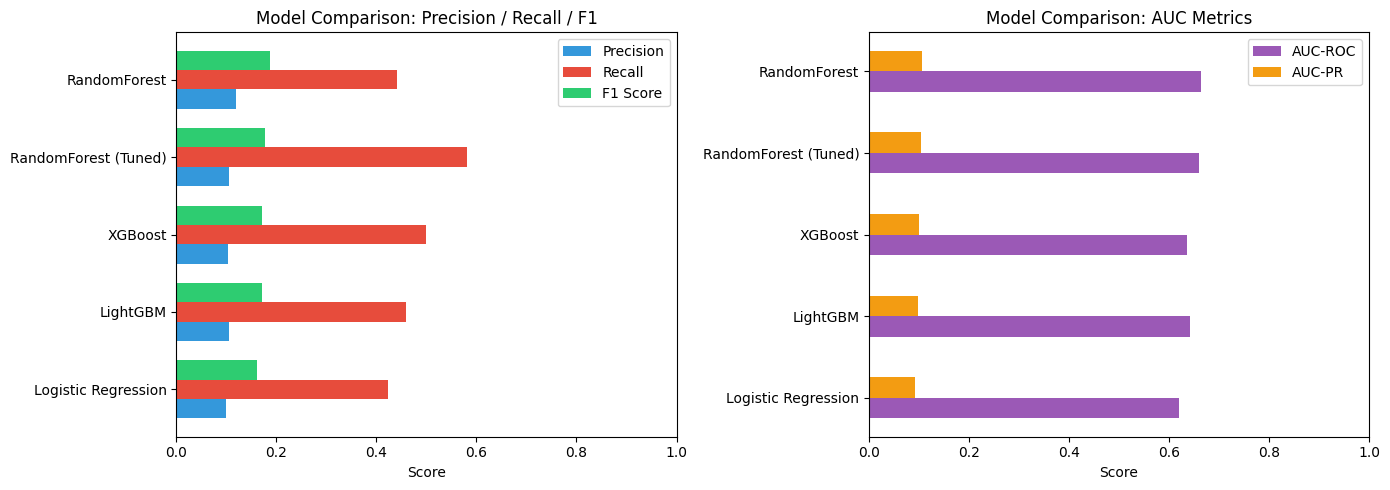

In [25]:
# Visualization: Compare all models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by F1
df_sorted = all_results_df.sort_values('F1_Score', ascending=True)
models = df_sorted['Model'].tolist()
y_pos = np.arange(len(models))

# Bar chart: F1, Precision, Recall
ax1 = axes[0]
height = 0.25
ax1.barh(y_pos - height, df_sorted['Precision'], height, label='Precision', color='#3498db')
ax1.barh(y_pos, df_sorted['Recall'], height, label='Recall', color='#e74c3c')
ax1.barh(y_pos + height, df_sorted['F1_Score'], height, label='F1 Score', color='#2ecc71')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(models)
ax1.set_xlabel('Score')
ax1.set_title('Model Comparison: Precision / Recall / F1')
ax1.legend()
ax1.set_xlim(0, 1)

# Bar chart: AUC
ax2 = axes[1]
ax2.barh(y_pos - height/2, df_sorted['AUC_ROC'], height, label='AUC-ROC', color='#9b59b6')
ax2.barh(y_pos + height/2, df_sorted['AUC_PR'], height, label='AUC-PR', color='#f39c12')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(models)
ax2.set_xlabel('Score')
ax2.set_title('Model Comparison: AUC Metrics')
ax2.legend()
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
f1_improvement = (rf_tuned_results['F1_Score'] - rf_results['F1_Score']) / rf_results['F1_Score'] * 100
recall_improvement = (rf_tuned_results['Recall'] - rf_results['Recall']) / rf_results['Recall'] * 100
prec_improvement = (rf_tuned_results['Precision'] - rf_results['Precision']) / rf_results['Precision'] * 100

print(f"F1_Score Improvement: {f1_improvement:.2f}%")
print(f"Recall Improvement: {recall_improvement:.2f}%")
print(f"Precision Improvement: {prec_improvement:.2f}%")



F1_Score Improvement: -5.35%
Recall Improvement: 31.72%
Precision Improvement: -12.00%


- **AUC-PR** is more informative than AUC-ROC for rare events
- Tree ensembles often beat linear models on tabular data
- Hyperparameter tuning can improve RECALL Rate by ~30%, which shifted precision, hence causing F1 score to decrease. 
- - We can take a look which features that added no significance and add interaction features.